# 📊 Notebook 1 — Analyse Exploratoire des Données (EDA)
---
**Projet** : Plateforme Nationale d'Information Immobilière — Sénégal
**Sources** : CoinAfrique · Expat-Dakar · Loger-Dakar · DakarVente · ImmoSénégal
**Objectif** : Explorer la structure des données collectées, identifier les distributions, les valeurs manquantes et les corrélations pour guider le prétraitement et la modélisation.

---
## Table des matières
1. Configuration et chargement
2. Vue d'ensemble du dataset
3. Analyse des valeurs manquantes
4. Distribution des variables numériques
5. Analyse du prix — variable cible
6. Séparation Vente / Location basée sur les données réelles
7. Analyse des variables catégorielles
8. Corrélations
9. Analyse géographique
10. Conclusions et recommandations


## 1. Configuration et chargement

In [1]:
import os, sys, django
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"]    = (13, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.environ.setdefault("DJANGO_SETTINGS_MODULE", "immobilier_project.settings")
django.setup()

from django.db import connections
from IPython import get_ipython
ip = get_ipython()
if ip:
    ip.events.register("pre_run_cell", lambda info: connections.close_all())
connections.close_all()
print("Environnement Django pret.")


Environnement Django pret.


In [2]:
from properties.models import (
    CoinAfriqueProperty, ExpatDakarProperty,
    LogerDakarProperty, DakarVenteProperty, ImmoSenegalProperty
)

def load_source(model, source, extra_fields=None):
    base      = ["id", "price", "surface_area", "bedrooms", "bathrooms",
                 "city", "property_type", "statut", "adresse",
                 "title", "description"]
    available = [f.name for f in model._meta.get_fields()]
    fields    = [f for f in (base + (extra_fields or [])) if f in available]
    rows      = list(model.objects.values(*fields))
    df        = pd.DataFrame(rows)
    df["source"] = source
    return df

df_coin  = load_source(CoinAfriqueProperty, "coinafrique", ["latitude", "longitude"])
df_expat = load_source(ExpatDakarProperty,  "expat_dakar")
df_loger = load_source(LogerDakarProperty,  "loger_dakar")
df_dv    = load_source(DakarVenteProperty,  "dakarvente",  ["transaction"])
df_immo  = load_source(ImmoSenegalProperty, "immosenegal", ["transaction"])

for df_ in [df_expat, df_loger, df_coin]:
    if "transaction" not in df_.columns:
        df_["transaction"] = None
for df_ in [df_expat, df_loger, df_dv, df_immo]:
    if "latitude"  not in df_.columns: df_["latitude"]  = None
    if "longitude" not in df_.columns: df_["longitude"] = None

df_raw = pd.concat(
    [df_coin, df_expat, df_loger, df_dv, df_immo],
    ignore_index=True
)
print(f"Dataset total  : {len(df_raw):,} annonces")
print(f"  CoinAfrique  : {len(df_coin):,}")
print(f"  Expat-Dakar  : {len(df_expat):,}")
print(f"  Loger-Dakar  : {len(df_loger):,}")
print(f"  DakarVente   : {len(df_dv):,}")
print(f"  ImmoSenegal  : {len(df_immo):,}")


Dataset total  : 8,118 annonces
  CoinAfrique  : 4,062
  Expat-Dakar  : 285
  Loger-Dakar  : 1,828
  DakarVente   : 1,871
  ImmoSenegal  : 72


## 2. Vue d'ensemble du dataset

In [3]:
print(f"Dimensions : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes")
print()
print("TYPES DE DONNÉES :")
print(df_raw.dtypes.to_string())


Dimensions : 8,118 lignes x 15 colonnes

TYPES DE DONNÉES :
id                   str
price              int64
surface_area     float64
bedrooms          object
bathrooms         object
city                 str
property_type        str
statut               str
adresse           object
title                str
description       object
latitude          object
longitude         object
source               str
transaction       object


In [4]:
print("APERCU DES PREMIERES LIGNES")
df_raw.head(5)

APERCU DES PREMIERES LIGNES


,id,price,surface_area,bedrooms,bathrooms,city,property_type,statut,adresse,title,description,latitude,longitude,source,transaction
0,af4017373fbb6793186c3c1eb06fdc0f,350000,"7,799.00",3.00,4.00,"Pikine, Sénégal","Pikine, Sénégal",Pro,"Pikine, Sénégal",Vente bureaux,"{""Je vends un entrepôt (hangar et dépôt ) il ...",14.76,-17.39,coinafrique,None
1,9c0070a26da967cbe6528beeb21fdee1,750000,70.00,2.00,2.00,"Mermoz-Sacré Coeur, Dakar, Sénégal","Mermoz-Sacré Coeur, Dakar, Sénégal",Pro,"Mermoz-Sacré Coeur, Dakar, Sénégal",Location appartements,"{""Je loue un très bel studio meublé à mermoz i...",14.70,-17.47,coinafrique,None
2,96e4ea48d10761e99b62df116c931068,2500000,180.00,4.00,5.00,"Yoff, Dakar, Sénégal","Yoff, Dakar, Sénégal",Pro,"Yoff, Dakar, Sénégal",Location appartement,"{""Je loue c'est magnifique appartement meublé ...",14.75,-17.49,coinafrique,None
3,b1fb148a1a21efc54e7febe368cb98bc,4000000,800.00,9.00,7.00,"Mermoz-Sacré Coeur, Dakar, Sénégal","Mermoz-Sacré Coeur, Dakar, Sénégal",Pro,"Mermoz-Sacré Coeur, Dakar, Sénégal",Location villa,"{""Je loue"",""Je loue""}",14.70,-17.47,coinafrique,None
4,654589599befdca633ef56bada661a47,30000,56.00,2.00,1.00,"Yoff, Dakar, Sénégal","Yoff, Dakar, Sénégal",Pro,"Yoff, Dakar, Sénégal",Location studio,"{""Je loue ce très magnifique studio meublé à y...",14.75,-17.49,coinafrique,None


In [5]:
print("STATISTIQUES DESCRIPTIVES")
df_raw[["price", "surface_area", "bedrooms", "bathrooms"]].describe().T


STATISTIQUES DESCRIPTIVES


,count,mean,std,min,25%,50%,75%,max
price,"8,118.00","37,901,743.74","129,800,625.07",1.00,"290,000.00","800,000.00","11,000,000.00","2,147,483,647.00"
surface_area,"6,144.00","8,706.76","174,648.88",0.00,35.00,150.00,210.00,"10,000,000.00"


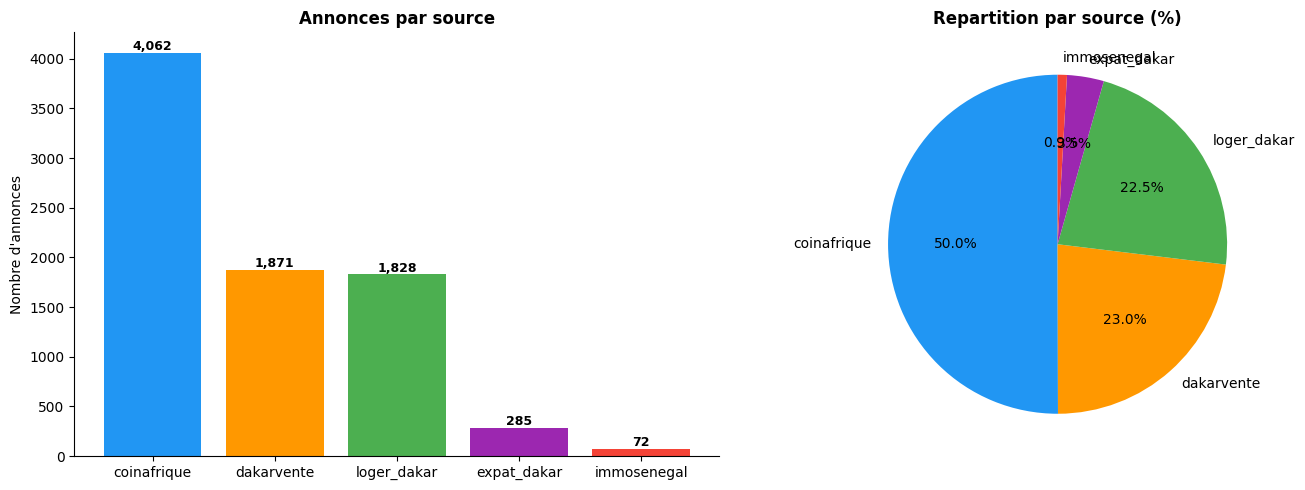

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df_raw["source"].value_counts()
colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0", "#F44336"]

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Annonces par source", fontweight="bold")
axes[0].set_ylabel("Nombre d'annonces")
for i, (s, c) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, c + 30, f"{c:,}", ha="center", fontweight="bold", fontsize=9)

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90)
axes[1].set_title("Repartition par source (%)", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/fig_01_repartition_sources.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Analyse des valeurs manquantes

In [7]:
df_work = df_raw[df_raw["price"].notna() & (df_raw["price"] > 0)].copy()

missing  = df_work.isnull().sum()
pct      = (missing / len(df_work) * 100).round(2)
miss_df  = (pd.DataFrame({"Manquants": missing, "Pourcentage (%)": pct})
            .query("`Manquants` > 0")
            .sort_values("Pourcentage (%)", ascending=False))

print("VALEURS MANQUANTES PAR VARIABLE :")
print(miss_df.to_string())


VALEURS MANQUANTES PAR VARIABLE :
              Manquants  Pourcentage (%)
transaction        8046            99.11
longitude          4056            49.96
latitude           4056            49.96
bathrooms          2623            32.31
bedrooms           2192            27.00
surface_area       1974            24.32
adresse             288             3.55
description          72             0.89
statut               15             0.18


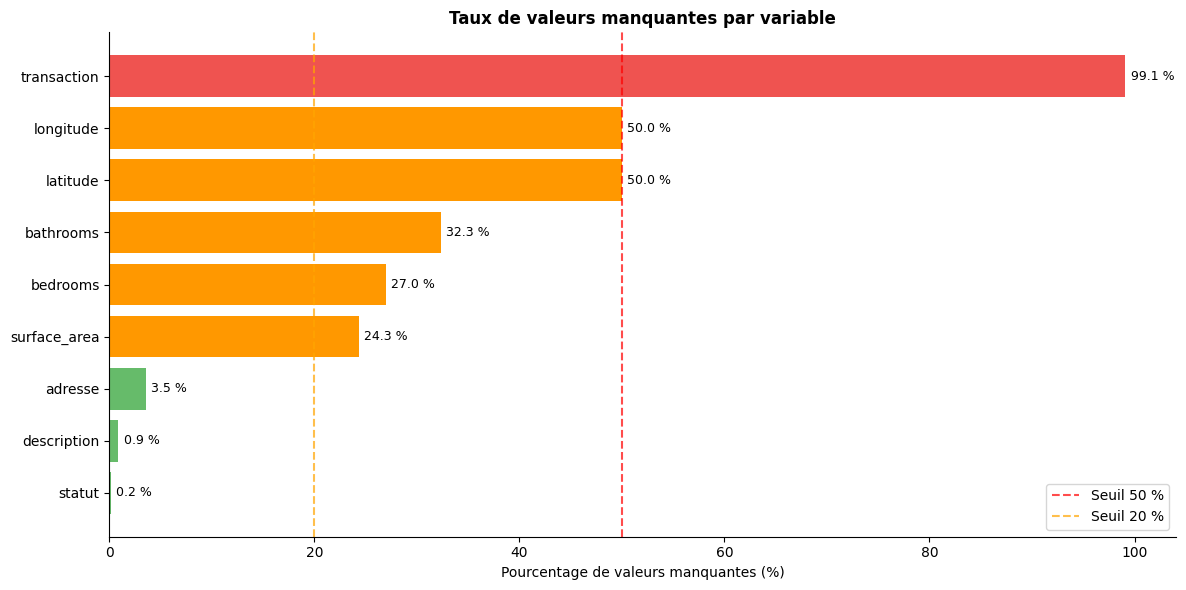

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
cols_m  = pct[pct > 0].sort_values(ascending=True)
col_map = ["#ef5350" if v > 50 else "#ff9800" if v > 20 else "#66bb6a"
           for v in cols_m]
bars    = ax.barh(cols_m.index, cols_m.values, color=col_map)
ax.set_xlabel("Pourcentage de valeurs manquantes (%)")
ax.set_title("Taux de valeurs manquantes par variable", fontweight="bold")
ax.axvline(50, color="red",    linestyle="--", alpha=0.7, label="Seuil 50 %")
ax.axvline(20, color="orange", linestyle="--", alpha=0.7, label="Seuil 20 %")
ax.legend()
for bar, val in zip(bars, cols_m.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f} %", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/fig_02_valeurs_manquantes.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
print("TAUX DE COMPLETUDE PAR SOURCE (variables cles) :")
key_cols = ["price", "surface_area", "bedrooms", "bathrooms", "city", "property_type"]
completude = df_work.groupby("source")[key_cols].apply(
    lambda x: (x.notna().sum() / len(x) * 100).round(1)
)
print(completude.to_string())


TAUX DE COMPLETUDE PAR SOURCE (variables cles) :
             price  surface_area  bedrooms  bathrooms   city  property_type
source                                                                     
coinafrique 100.00         70.60     75.80      70.50 100.00         100.00
dakarvente  100.00         92.00     48.70      47.80 100.00         100.00
expat_dakar 100.00         63.50     72.30      64.20 100.00         100.00
immosenegal 100.00          1.40      0.00       0.00 100.00         100.00
loger_dakar 100.00         75.20     94.60      85.10 100.00         100.00


## 4. Distribution des variables numériques

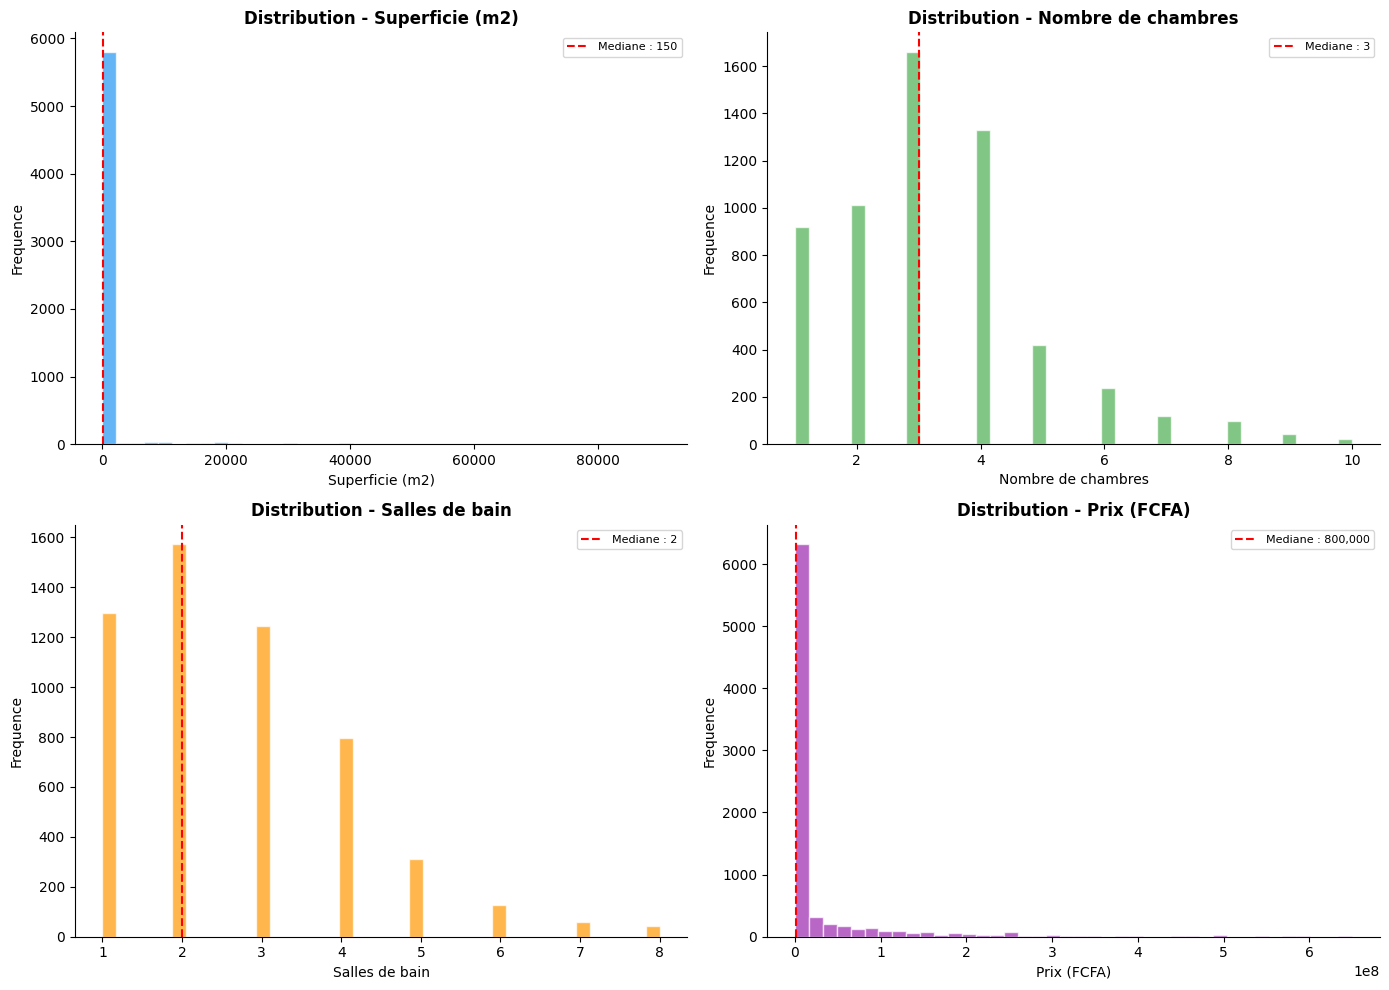

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
vars_num = [
    ("surface_area", "Superficie (m2)",       "#2196F3"),
    ("bedrooms",     "Nombre de chambres",     "#4CAF50"),
    ("bathrooms",    "Salles de bain",          "#FF9800"),
    ("price",        "Prix (FCFA)",             "#9C27B0"),
]
for ax, (col, label, color) in zip(axes.flatten(), vars_num):
    data = df_work[col].dropna()
    q99  = data.quantile(0.99)
    ax.hist(data[data <= q99], bins=40, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(data.median(), color="red", linestyle="--",
               label=f"Mediane : {data.median():,.0f}")
    ax.set_title(f"Distribution - {label}", fontweight="bold")
    ax.set_xlabel(label); ax.set_ylabel("Frequence")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/fig_03_distributions_numeriques.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Analyse du prix — variable cible

In [11]:
df_p  = df_work[df_work["price"] > 0].copy()
stats = df_p["price"].describe()

print("=" * 55)
print("  STATISTIQUES DU PRIX (FCFA)")
print("=" * 55)
print(f"  Observations  : {len(df_p):>15,}")
print(f"  Moyenne       : {stats['mean']:>15,.0f}")
print(f"  Mediane       : {df_p['price'].median():>15,.0f}")
print(f"  Ecart-type    : {stats['std']:>15,.0f}")
print(f"  Minimum       : {stats['min']:>15,.0f}")
print(f"  Maximum       : {stats['max']:>15,.0f}")
print(f"  Q25           : {stats['25%']:>15,.0f}")
print(f"  Q75           : {stats['75%']:>15,.0f}")
cv = stats["std"] / stats["mean"]
print(f"  CV (std/moy)  : {cv:>15.2f}  (> 1.5 = forte heterogeneite)")
print()
print("La forte heterogeneite confirme que vente et location sont melangees.")
print("=> La separation par type de transaction est indispensable.")


  STATISTIQUES DU PRIX (FCFA)
  Observations  :           8,118
  Moyenne       :      37,901,744
  Mediane       :         800,000
  Ecart-type    :     129,800,625
  Minimum       :               1
  Maximum       :   2,147,483,647
  Q25           :         290,000
  Q75           :      11,000,000
  CV (std/moy)  :            3.42  (> 1.5 = forte heterogeneite)

La forte heterogeneite confirme que vente et location sont melangees.
=> La separation par type de transaction est indispensable.


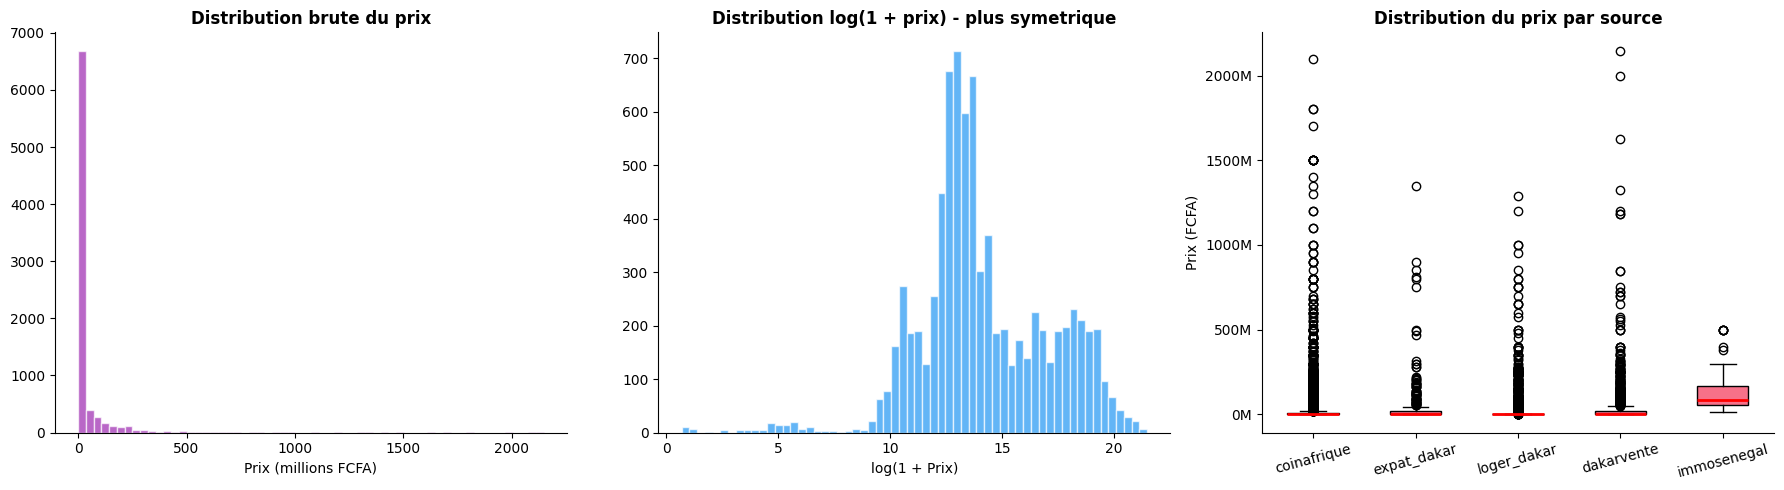

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_p["price"] / 1e6, bins=60, color="#9C27B0", alpha=0.7, edgecolor="white")
axes[0].set_title("Distribution brute du prix", fontweight="bold")
axes[0].set_xlabel("Prix (millions FCFA)")

axes[1].hist(np.log1p(df_p["price"]), bins=60, color="#2196F3", alpha=0.7, edgecolor="white")
axes[1].set_title("Distribution log(1 + prix) - plus symetrique", fontweight="bold")
axes[1].set_xlabel("log(1 + Prix)")

src_names = df_p["source"].unique()
data_src  = [df_p[df_p["source"] == s]["price"].values for s in src_names]
axes[2].boxplot(data_src, labels=src_names, patch_artist=True,
                medianprops={"color": "red", "linewidth": 2})
axes[2].set_title("Distribution du prix par source", fontweight="bold")
axes[2].set_ylabel("Prix (FCFA)")
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/fig_04_analyse_prix.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Séparation Vente / Location basée sur les données réelles

La séparation repose sur trois sources d'information, consultées dans l'ordre de priorité :
1. La colonne `transaction` explicite (disponible sur DakarVente et ImmoSénégal)
2. Le titre de l'annonce
3. La description


In [13]:
# Mots-cles de detection de la transaction
KW_LOCATION = ["louer", "location", "locat", "a louer", "meuble", "meublee"]
KW_VENTE    = ["vendre", "vente", "a vendre", "achat", "cession", "acquisition"]

def detect_transaction(row):
    """
    Detecte la nature de la transaction (vente ou location) depuis :
    1. La colonne transaction explicite si elle existe (DakarVente, ImmoSenegal)
    2. Le titre de l annonce
    3. La description
    Les accents sont retires pour eviter les problemes d encodage.
    """
    txn = str(row.get("transaction") or "").lower().strip()
    if txn in ("vente", "location"):
        return txn

    title = (str(row.get("title") or "")
             .lower()
             .replace("é", "e").replace("à", "a")
             .replace("é", "e").replace("ê", "e"))
    if any(k in title for k in KW_LOCATION): return "location"
    if any(k in title for k in KW_VENTE):    return "vente"

    desc = (str(row.get("description") or "")
            .lower()
            .replace("é", "e").replace("à", "a")
            .replace("é", "e").replace("ê", "e"))
    if any(k in desc for k in KW_LOCATION): return "location"
    if any(k in desc for k in KW_VENTE):    return "vente"

    return "inconnu"


In [14]:
df_p["transaction"] = df_p.apply(detect_transaction, axis=1)

print("REPARTITION PAR TYPE DE TRANSACTION :")
print(df_p["transaction"].value_counts().to_string())
print()
print(f"Taux de classification  : {(df_p['transaction'] != 'inconnu').mean()*100:.1f} %")
print(f"Non classifies          : {(df_p['transaction'] == 'inconnu').sum():,} annonces")
print()
print("REPARTITION PAR SOURCE ET TRANSACTION :")
pivot = df_p.groupby(["source", "transaction"]).size().unstack(fill_value=0)
print(pivot.to_string())


REPARTITION PAR TYPE DE TRANSACTION :
transaction
location    5284
vente       2314
inconnu      520

Taux de classification  : 93.6 %
Non classifies          : 520 annonces

REPARTITION PAR SOURCE ET TRANSACTION :
transaction  inconnu  location  vente
source                               
coinafrique      289      2876    897
dakarvente         9       821   1041
expat_dakar       35       181     69
immosenegal        0        14     58
loger_dakar      187      1392    249


Segment VENTE      : 2,314 annonces
Segment LOCATION   : 5,284 annonces
Non classifies     : 520 annonces
EXEMPLES D'ANNONCES NON CLASSIFIEES (a analyser) :
          source           title      price
59   coinafrique   Terrain 625m²   45000000
83   coinafrique       Terrain -      35000
104  coinafrique   Terrain 150m²   26000000
109  coinafrique   Appartement à     450000
121  coinafrique        Studio à     250000
142  coinafrique       Terrain -     115000
144  coinafrique       Terrain à   20000000
159  coinafrique  Terrains 318m²  300000000
162  coinafrique    Terrains 170   95000000
166  coinafrique    Terrains 201  110000000


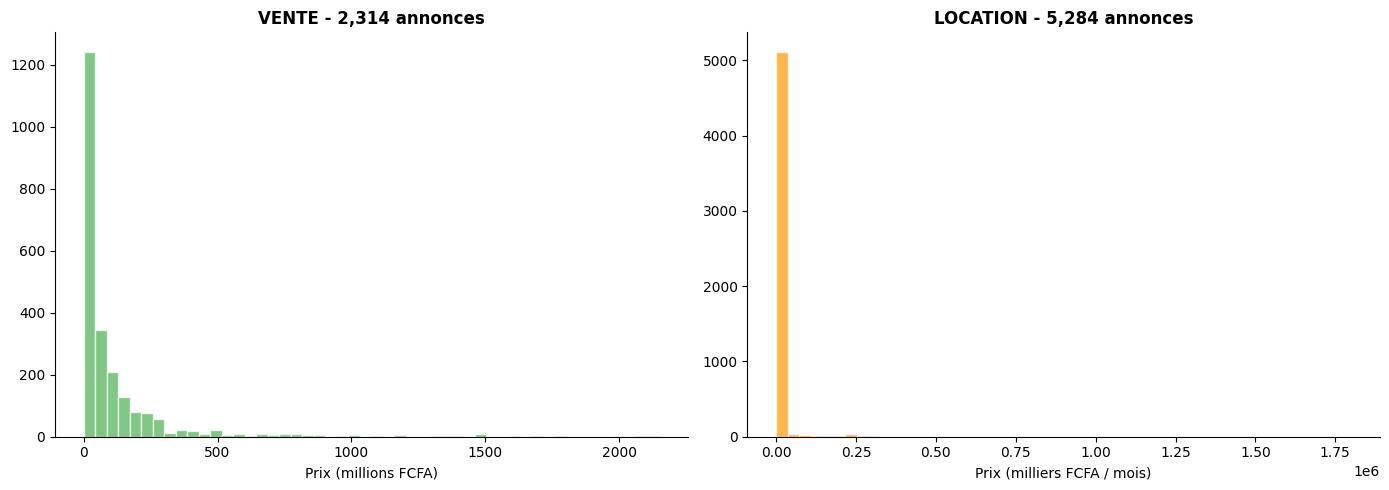

In [19]:
df_vente    = df_p[df_p["transaction"] == "vente"].copy()
df_location = df_p[df_p["transaction"] == "location"].copy()
df_inconnu  = df_p[df_p["transaction"] == "inconnu"].copy()

print(f"Segment VENTE      : {len(df_vente):,} annonces")
print(f"Segment LOCATION   : {len(df_location):,} annonces")
print(f"Non classifies     : {len(df_inconnu):,} annonces")

if len(df_inconnu) > 0:
    print(f"EXEMPLES D'ANNONCES NON CLASSIFIEES (a analyser) :")
    print(df_inconnu[["source", "title", "price"]].head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_vente["price"] / 1e6, bins=50,
             color="#4CAF50", alpha=0.7, edgecolor="white")
axes[0].set_title(f"VENTE - {len(df_vente):,} annonces", fontweight="bold")
axes[0].set_xlabel("Prix (millions FCFA)")

axes[1].hist(df_location["price"] / 1e3, bins=50,
             color="#FF9800", alpha=0.7, edgecolor="white")
axes[1].set_title(f"LOCATION - {len(df_location):,} annonces", fontweight="bold")
axes[1].set_xlabel("Prix (milliers FCFA / mois)")

plt.tight_layout()
plt.savefig("../outputs/fig_05_vente_location.png", dpi=150, bbox_inches="tight")
plt.show()

# On retient le segment vente pour les analyses suivantes
df_v = df_vente.copy()


## 7. Analyse des variables catégorielles

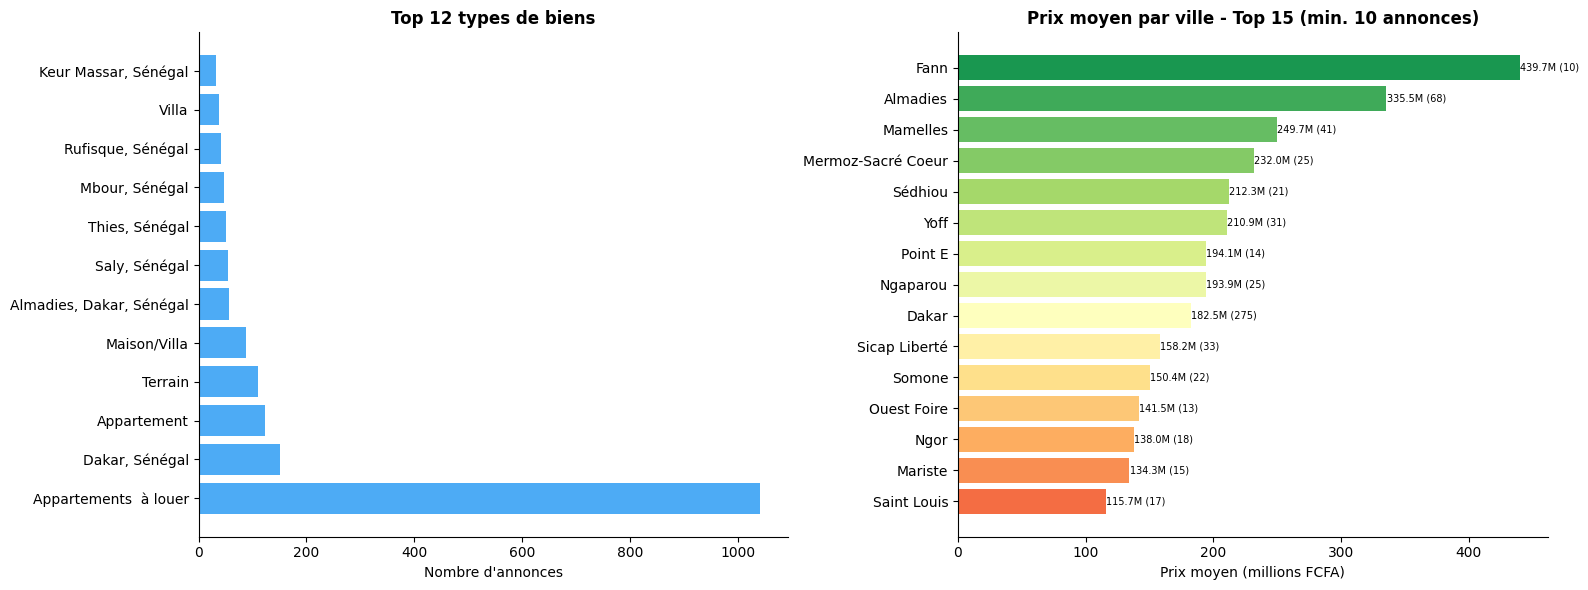

In [20]:
df_v["city_clean"] = (df_v["city"].fillna("")
                      .str.strip().str.split(",").str[0]
                      .str.strip().str.title())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pt = df_v["property_type"].value_counts().head(12)
axes[0].barh(pt.index, pt.values, color="#2196F3", alpha=0.8)
axes[0].set_title("Top 12 types de biens", fontweight="bold")
axes[0].set_xlabel("Nombre d'annonces")

top_c = (df_v.groupby("city_clean")["price"]
         .agg(["mean", "count"])
         .query("count >= 10")
         .sort_values("mean", ascending=True)
         .tail(15))
bars  = axes[1].barh(
    top_c.index, top_c["mean"] / 1e6,
    color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top_c))))
axes[1].set_title("Prix moyen par ville - Top 15 (min. 10 annonces)", fontweight="bold")
axes[1].set_xlabel("Prix moyen (millions FCFA)")
for bar, (_, row) in zip(bars, top_c.iterrows()):
    axes[1].text(row["mean"] / 1e6 + 0.1,
                 bar.get_y() + bar.get_height() / 2,
                 f"{row['mean']/1e6:.1f}M ({int(row['count'])})",
                 va="center", fontsize=7)
plt.tight_layout()
plt.savefig("../outputs/fig_06_categories.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Corrélations

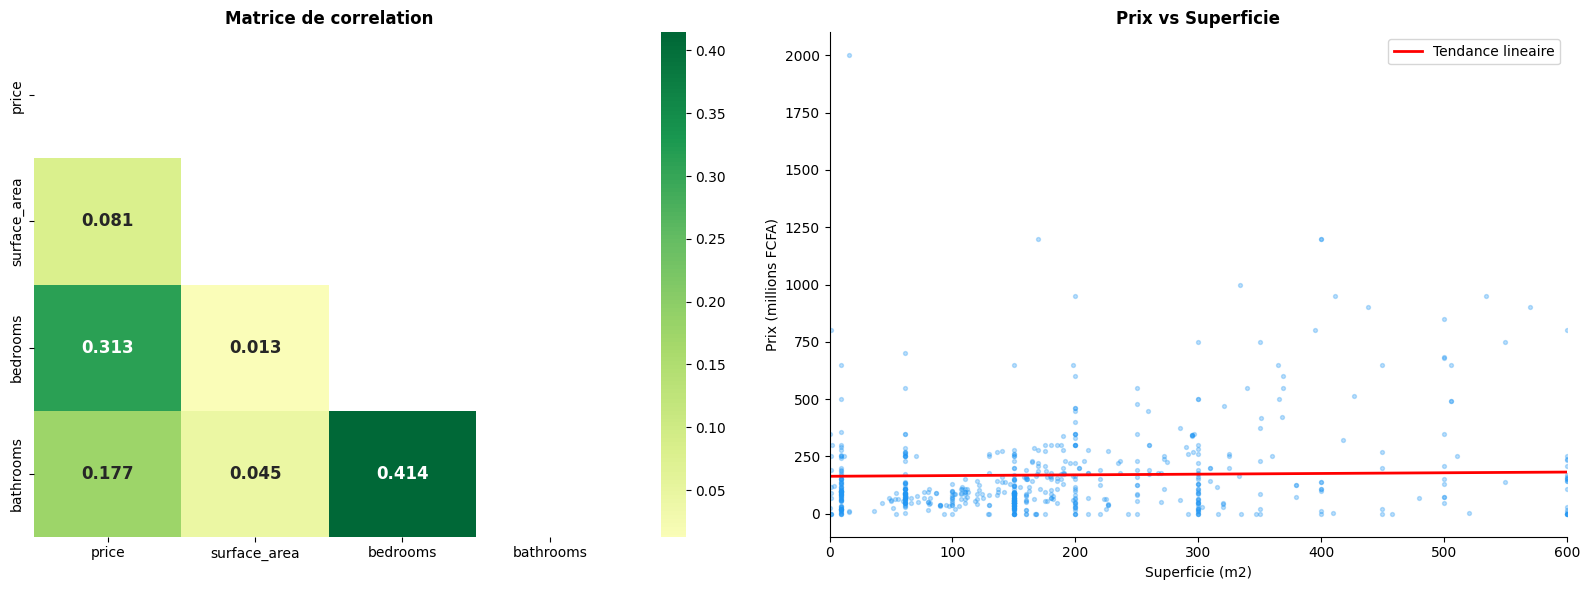

Correlations avec le prix :
  surface_area    : 0.0814
  bedrooms        : 0.3129
  bathrooms       : 0.1773


In [21]:
df_corr = df_v[["price", "surface_area", "bedrooms", "bathrooms"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdYlGn", center=0,
            ax=axes[0], mask=mask, annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title("Matrice de correlation", fontweight="bold")

axes[1].scatter(df_corr["surface_area"], df_corr["price"] / 1e6,
                alpha=0.3, s=8, color="#2196F3")
z     = np.polyfit(df_corr["surface_area"], df_corr["price"] / 1e6, 1)
x_lim = df_corr["surface_area"].quantile(0.95)
x_l   = np.linspace(0, x_lim, 100)
axes[1].plot(x_l, np.poly1d(z)(x_l), "r-", lw=2, label="Tendance lineaire")
axes[1].set_xlabel("Superficie (m2)")
axes[1].set_ylabel("Prix (millions FCFA)")
axes[1].set_title("Prix vs Superficie", fontweight="bold")
axes[1].set_xlim(0, x_lim)
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/fig_07_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlations avec le prix :")
for col in ["surface_area", "bedrooms", "bathrooms"]:
    r = df_corr[["price", col]].corr().iloc[0, 1]
    print(f"  {col:<15} : {r:.4f}")


## 9. Analyse géographique

Annonces avec coordonnees GPS : 893 / 2,314


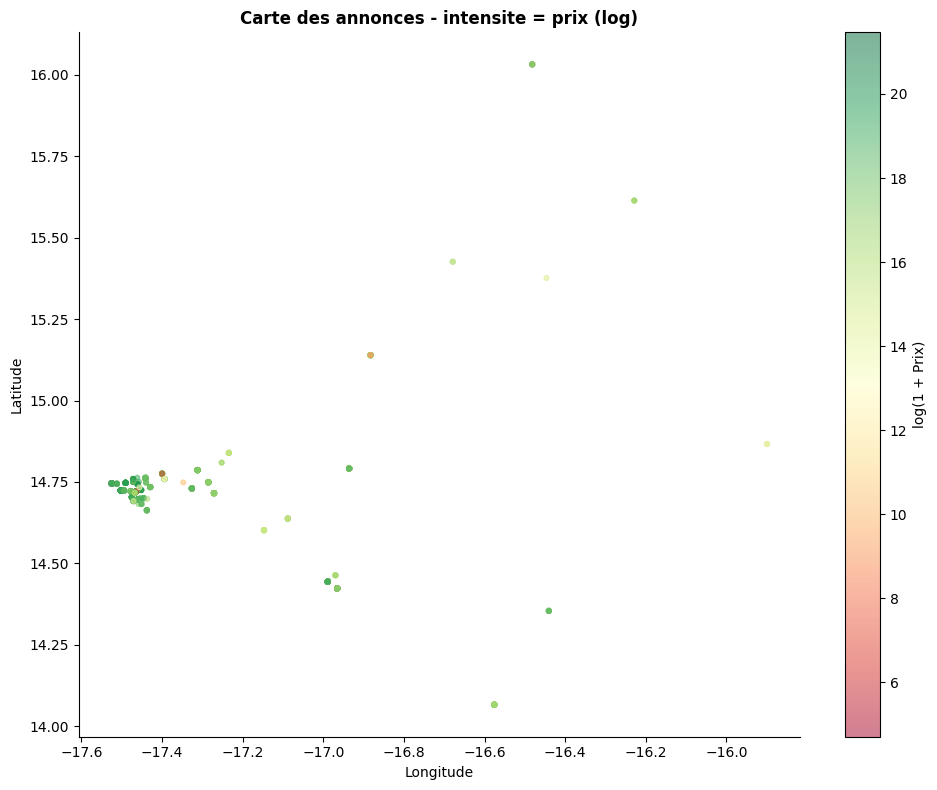

In [22]:
df_geo = df_v.copy()
df_geo["lat"] = pd.to_numeric(df_geo.get("latitude"),  errors="coerce")
df_geo["lon"] = pd.to_numeric(df_geo.get("longitude"), errors="coerce")
df_geo = df_geo[
    df_geo["lat"].between(13.5, 16.5) &
    df_geo["lon"].between(-18,  -15)
]
print(f"Annonces avec coordonnees GPS : {len(df_geo):,} / {len(df_v):,}")

if len(df_geo) > 10:
    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(df_geo["lon"], df_geo["lat"],
                    c=np.log1p(df_geo["price"]), cmap="RdYlGn",
                    alpha=0.5, s=12)
    plt.colorbar(sc, ax=ax, label="log(1 + Prix)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title("Carte des annonces - intensite = prix (log)",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig("../outputs/fig_08_carte_geographique.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Coordonnees GPS insuffisantes pour la carte.")
